# 02 — Experiment 1: Preamble Length

Does shifting documents to higher absolute token positions affect the U-curve?

A long preamble before the document list pushes all documents further into the
context window. If the model tracks **absolute token position** (RoPE decay),
primacy should weaken. If it reanchors to **relative list position** (structural
hypothesis), the U-curve shape should be stable.

- **Dataset:** 196 questions, 30 documents each (Wikipedia 2024-2025)
- **Preamble conditions:** none, short (~130 words), long (~1290 words)
- **Preamble source:** "History of paper" Wikipedia article (no domain overlap)
- **Positions:** 1, 5, 15, 25, 30 (edges + slopes + middle trough)
- **196 questions × 5 positions × 3 conditions = 2,940 API calls**

**Key controls:**
- Distractor order fixed per question across all positions and conditions
- Three preamble levels allow trend detection (dose-response) and help
  distinguish positional shift from irrelevant-content degradation

In [1]:
import sys, os, json, random
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from litm.prompts import format_prompt
from litm.scoring import score
from litm.api import get_client, query_model

client, model = get_client("gpt-4o-mini")

In [2]:
# Load dataset and preambles
with open("../DatasetBuilder/dataset/final_dataset_30.json", "r", encoding="utf-8") as f:
    questions = json.load(f)

with open("../data_misc/preambles.json", "r", encoding="utf-8") as f:
    preambles = json.load(f)

POSITIONS = [0, 4, 14, 24, 29]  # 0-indexed → displayed as 1, 5, 15, 25, 30
TOTAL_DOCS = 30
CONDITIONS = ["none", "short", "long"]

print(f"Questions: {len(questions)}")
print(f"Positions: {[p+1 for p in POSITIONS]}")
print(f"Conditions: {CONDITIONS}")
print(f"Total requests: {len(questions) * len(POSITIONS) * len(CONDITIONS)}")
print(f"\nPreamble lengths (words):")
for name in CONDITIONS:
    wc = len(preambles[name].split()) if preambles[name] else 0
    print(f"  {name:8s}: {wc} words")

Questions: 196
Positions: [1, 5, 15, 25, 30]
Conditions: ['none', 'short', 'long']
Total requests: 2940

Preamble lengths (words):
  none    : 0 words
  short   : 132 words
  long    : 1288 words


## Run Experiment

For each question, distractors are shuffled once (fixed per question). The gold doc
is then inserted at each target position, and each prompt is tested with all 3
preamble conditions. Checkpointed every 50 questions.

In [3]:
os.makedirs("../results", exist_ok=True)
CHECKPOINT_PATH = "../results/exp1_checkpoint.csv"
RESULTS_PATH = "../results/exp1_preamble_length.csv"

# Resume from checkpoint if available
completed = set()
results = []

if os.path.exists(CHECKPOINT_PATH):
    prev = pd.read_csv(CHECKPOINT_PATH)
    results = prev.to_dict("records")
    completed = {(r["question_id"], r["gold_position"], r["condition"]) for r in results}
    print(f"Resuming from checkpoint: {len(results)} trials already done")
else:
    print("Starting fresh — no checkpoint found")

for qi, q in enumerate(tqdm(questions, desc="Questions")):
    # Fix distractor order per question — same across all positions and conditions
    random.seed(42 + qi)
    distractors = random.sample(q["distractors"], len(q["distractors"]))

    for pos in POSITIONS:
        pos_label = pos + 1

        # Insert gold doc into the fixed distractor sequence
        docs = distractors.copy()
        docs.insert(pos, q["gold_passage"])

        for cond in CONDITIONS:
            if (q["id"], pos_label, cond) in completed:
                continue

            preamble = preambles[cond]
            prompt = format_prompt(docs, q["question"], preamble=preamble)
            response = query_model(client, model, prompt)
            correct = score(response, q["answer_aliases"])

            results.append({
                "question_id": q["id"],
                "question": q["question"],
                "expected": q["answer"],
                "response": response,
                "correct": correct,
                "gold_position": pos_label,
                "condition": cond,
            })

    # Checkpoint every 50 questions
    if (qi + 1) % 50 == 0:
        pd.DataFrame(results).to_csv(CHECKPOINT_PATH, index=False)
        print(f"  Checkpoint saved at question {qi + 1}")

df = pd.DataFrame(results)
df.to_csv(RESULTS_PATH, index=False)
print(f"\nTotal trials: {len(df)} (expected {len(questions) * len(POSITIONS) * len(CONDITIONS)})")
print(f"Overall accuracy: {df['correct'].mean():.1%}")
print(f"\nAccuracy by condition:")
for cond in CONDITIONS:
    sub = df[df["condition"] == cond]
    print(f"  {cond:8s}: {sub['correct'].mean():.1%} ({int(sub['correct'].sum())}/{len(sub)})")

Starting fresh — no checkpoint found


Questions:   0%|          | 0/196 [00:00<?, ?it/s]

API error (attempt 1): Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-xLgXsOhrWLf58wJ3iHGasqbl on tokens per min (TPM): Limit 200000, Used 194908, Requested 5791. Please try again in 209ms. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}. Retrying in 2s...
  Checkpoint saved at question 50
API error (attempt 1): Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-xLgXsOhrWLf58wJ3iHGasqbl on tokens per min (TPM): Limit 200000, Used 194214, Requested 5925. Please try again in 41ms. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}. Retrying in 2s...
API error (attempt 1): Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-xLgXsOhrWLf58wJ3iHGasqbl on tokens per min (TPM): Limit 2000

## Plot: Overlaid U-Curves by Preamble Condition

If absolute position matters, the curves should diverge — especially at position 1
(primacy weakening as preamble grows). If relative position matters, the curves
should overlap.

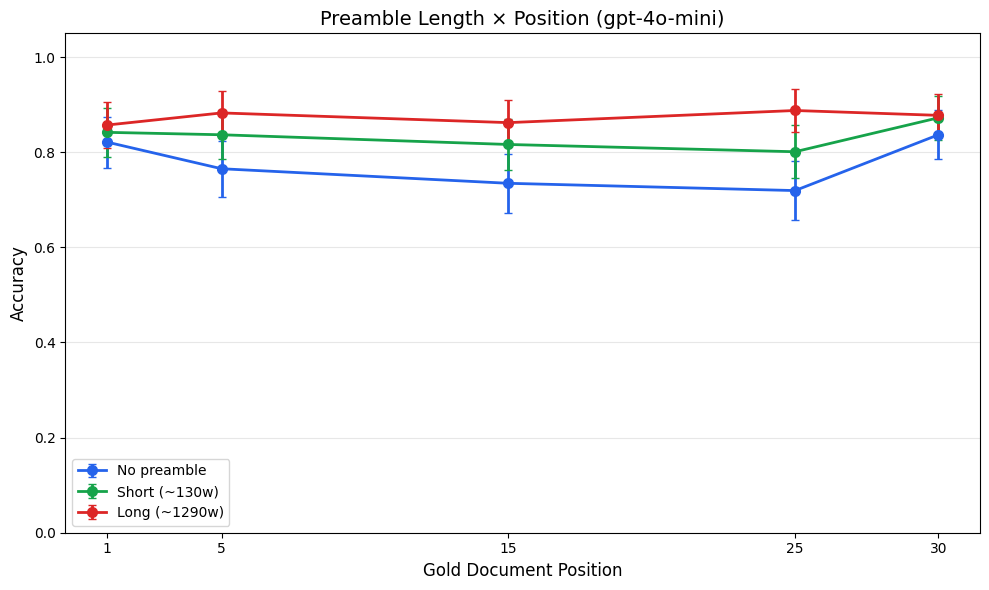

In [4]:
# If loading from saved results:
# df = pd.read_csv("../results/exp1_preamble_length.csv")

COLORS = {"none": "#2563eb", "short": "#16a34a", "long": "#dc2626"}
LABELS = {"none": "No preamble", "short": "Short (~130w)", "long": "Long (~1290w)"}

fig, ax = plt.subplots(figsize=(10, 6))

for cond in CONDITIONS:
    sub = df[df["condition"] == cond]
    acc = sub.groupby("gold_position")["correct"].agg(["mean", "count"])
    acc["se"] = (acc["mean"] * (1 - acc["mean"]) / acc["count"]) ** 0.5

    ax.errorbar(
        acc.index, acc["mean"],
        yerr=1.96 * acc["se"],
        marker="o", linewidth=2, markersize=7, capsize=3,
        color=COLORS[cond], label=LABELS[cond]
    )

ax.set_xlabel("Gold Document Position", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title(f"Preamble Length × Position ({model})", fontsize=14)
ax.set_xticks(sorted(df["gold_position"].unique()))
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../results/exp1_preamble_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Primacy and Recency Analysis

Compare accuracy at position 1 (primacy) and position 30 (recency) across
preamble conditions. If RoPE decay drives the effect, primacy should weaken
with longer preambles while recency stays stable.

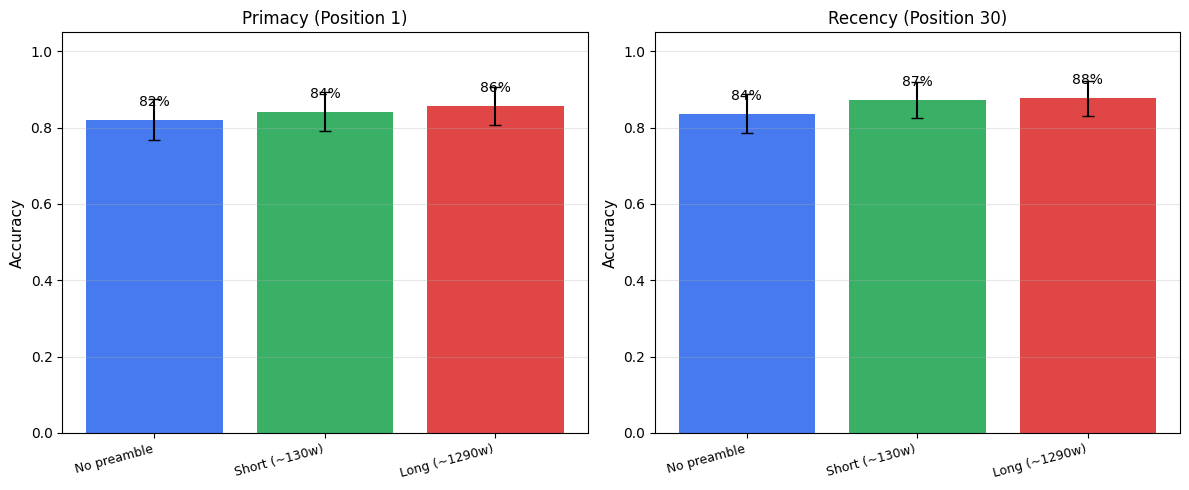

Condition           Primacy (1)  Recency (30)   U-effect
-------------------------------------------------------
No preamble              82.1%        83.7%     +9.4%
Short (~130w)            84.2%        87.2%     +4.1%
Long (~1290w)            85.7%        87.8%     +0.5%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (pos, label) in zip(axes, [(1, "Primacy (Position 1)"), (30, "Recency (Position 30)")]):
    accs = []
    for cond in CONDITIONS:
        sub = df[(df["condition"] == cond) & (df["gold_position"] == pos)]
        acc = sub["correct"].mean()
        se = (acc * (1 - acc) / len(sub)) ** 0.5
        accs.append((acc, se))

    bars = ax.bar(range(len(CONDITIONS)), [a[0] for a in accs],
                  yerr=[1.96 * a[1] for a in accs],
                  color=[COLORS[c] for c in CONDITIONS], capsize=4, alpha=0.85)
    ax.set_xticks(range(len(CONDITIONS)))
    ax.set_xticklabels([LABELS[c] for c in CONDITIONS], rotation=15, ha="right", fontsize=9)
    ax.set_ylabel("Accuracy", fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)

    for i, (acc, se) in enumerate(accs):
        ax.annotate(f"{acc:.0%}", (i, acc), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../results/exp1_primacy_recency.png", dpi=150, bbox_inches="tight")
plt.show()

# Print table
print(f"{'Condition':<18s} {'Primacy (1)':>12s} {'Recency (30)':>13s} {'U-effect':>10s}")
print("-" * 55)
for cond in CONDITIONS:
    sub = df[df["condition"] == cond]
    primacy = sub[sub["gold_position"] == 1]["correct"].mean()
    recency = sub[sub["gold_position"] == 30]["correct"].mean()
    edge = (primacy + recency) / 2
    middle = sub[sub["gold_position"] == 15]["correct"].mean()
    print(f"{LABELS[cond]:<18s} {primacy:>11.1%} {recency:>12.1%} {edge - middle:>+9.1%}")

## Statistical Tests

In [10]:
from scipy.stats import chi2, chi2_contingency

# 1. Cochran Q per condition (does position matter within each preamble condition?)
print("=" * 65)
print("1. Cochran Q per preamble condition (position effect within each)")
print("=" * 65)
positions = sorted(df["gold_position"].unique())
k = len(positions)

for cond in CONDITIONS:
    sub = df[df["condition"] == cond]
    pivot = sub.pivot(index="question_id", columns="gold_position", values="correct").astype(int)
    col_sums = pivot.sum(axis=0)
    row_sums = pivot.sum(axis=1)
    T = row_sums.sum()
    Q = ((k - 1) * (k * (col_sums**2).sum() - T**2)) / (k * T - (row_sums**2).sum())
    p = 1 - chi2.cdf(Q, k - 1)
    print(f"  {LABELS[cond]:<18s}: Q={Q:.3f}, df={k-1}, p={p:.6f} {'*' if p < 0.05 else ''}")

# 2. Does preamble condition affect overall accuracy? (Cochran Q across conditions)
print(f"\n{'=' * 65}")
print("2. Cochran Q across preamble conditions (does preamble matter?)")
print("=" * 65)

df["trial_id"] = df["question_id"] + "__pos" + df["gold_position"].astype(str)
pivot_cond = df.pivot(index="trial_id", columns="condition", values="correct").astype(int)
k_c = len(CONDITIONS)
col_sums_c = pivot_cond.sum(axis=0)
row_sums_c = pivot_cond.sum(axis=1)
T_c = row_sums_c.sum()
Q_c = ((k_c - 1) * (k_c * (col_sums_c**2).sum() - T_c**2)) / (k_c * T_c - (row_sums_c**2).sum())
p_c = 1 - chi2.cdf(Q_c, k_c - 1)
print(f"  Q={Q_c:.3f}, df={k_c-1}, p={p_c:.6f} {'*' if p_c < 0.05 else ''}")

# 3. McNemar: none vs long preamble at position 1 and 30
print(f"\n{'=' * 65}")
print("3. McNemar pairwise: none vs long preamble")
print("=" * 65)

for pos in [1, 30]:
    none_sub = df[(df["condition"] == "none") & (df["gold_position"] == pos)].set_index("question_id")["correct"]
    long_sub = df[(df["condition"] == "long") & (df["gold_position"] == pos)].set_index("question_id")["correct"]
    merged = pd.DataFrame({"none": none_sub, "long": long_sub}).dropna()
    b = ((merged["none"] == True) & (merged["long"] == False)).sum()
    c = ((merged["none"] == False) & (merged["long"] == True)).sum()
    if b + c > 0:
        stat = (abs(b - c) - 1)**2 / (b + c)
        p = 1 - chi2.cdf(stat, 1)
    else:
        stat, p = 0, 1.0
    print(f"  Position {pos:2d}: none_only={b}, long_only={c}, McNemar={stat:.3f}, p={p:.6f}")

# McNemar: none vs long at middle positions (where the effect concentrates)                                                                                                                               
print("\nMcNemar pairwise: none vs long preamble (middle positions)")                                                                                                                                       
print("-" * 65)
                                                                                                                                                                                                            
for pos in [5, 15, 25]:
    none_sub = df[(df["condition"] == "none") & (df["gold_position"] == pos)].set_index("question_id")["correct"]                                                                                         
    long_sub = df[(df["condition"] == "long") & (df["gold_position"] == pos)].set_index("question_id")["correct"]
    merged = pd.DataFrame({"none": none_sub, "long": long_sub}).dropna()
    b = ((merged["none"] == True) & (merged["long"] == False)).sum()
    c = ((merged["none"] == False) & (merged["long"] == True)).sum()
    if b + c > 0:
        stat = (abs(b - c) - 1)**2 / (b + c)
        p = 1 - chi2.cdf(stat, 1)
    else:
        stat, p = 0, 1.0
    none_acc = none_sub.mean()
    long_acc = long_sub.mean()
    print(f"  Position {pos:2d}: none={none_acc:.1%}, long={long_acc:.1%}, "
        f"delta={long_acc-none_acc:+.1%}, none_only={b}, long_only={c}, "
        f"McNemar={stat:.3f}, p={p:.6f} {'*' if p < 0.05 else ''}")

# 4. U-effect comparison across conditions
print(f"\n{'=' * 65}")
print("4. U-effect by condition")
print("=" * 65)
for cond in CONDITIONS:
    sub = df[df["condition"] == cond]
    edge = sub[sub["gold_position"].isin([1, 30])]["correct"].mean()
    middle = sub[sub["gold_position"] == 15]["correct"].mean()
    print(f"  {LABELS[cond]:<18s}: edge={edge:.1%}, middle={middle:.1%}, effect={edge-middle:+.1%}")

1. Cochran Q per preamble condition (position effect within each)
  No preamble       : Q=27.237, df=4, p=0.000018 *
  Short (~130w)     : Q=9.433, df=4, p=0.051135 
  Long (~1290w)     : Q=3.392, df=4, p=0.494426 

2. Cochran Q across preamble conditions (does preamble matter?)
  Q=117.529, df=2, p=0.000000 *

3. McNemar pairwise: none vs long preamble
  Position  1: none_only=2, long_only=9, McNemar=3.273, p=0.070440
  Position 30: none_only=3, long_only=11, McNemar=3.500, p=0.061369

McNemar pairwise: none vs long preamble (middle positions)
-----------------------------------------------------------------
  Position  5: none=76.5%, long=88.3%, delta=+11.7%, none_only=0, long_only=23, McNemar=21.043, p=0.000004 *
  Position 15: none=73.5%, long=86.2%, delta=+12.8%, none_only=1, long_only=26, McNemar=21.333, p=0.000004 *
  Position 25: none=71.9%, long=88.8%, delta=+16.8%, none_only=0, long_only=33, McNemar=31.030, p=0.000000 *

4. U-effect by condition
  No preamble       : edge=82.

In [11]:
# Overall accuracy comparison between conditions (two-sided)                                                                                                                                              
print("Overall accuracy comparison between preamble conditions")
print("=" * 65)
                                                                                                                                                                                                            
# Cochran Q already showed conditions differ (p < 0.000001)
# Now do pairwise McNemar tests with Bonferroni correction                                                                                                                                                
                  
pairs = [("none", "short"), ("none", "long"), ("short", "long")]
n_comparisons = len(pairs)

for cond_a, cond_b in pairs:
    a_correct = df[df["condition"] == cond_a].set_index(["question_id", "gold_position"])["correct"]
    b_correct = df[df["condition"] == cond_b].set_index(["question_id", "gold_position"])["correct"]
    merged = pd.DataFrame({"a": a_correct, "b": b_correct}).dropna()

    b_only = ((merged["a"] == False) & (merged["b"] == True)).sum()  # b right, a wrong
    a_only = ((merged["a"] == True) & (merged["b"] == False)).sum()  # a right, b wrong
    if a_only + b_only > 0:
        stat = (abs(a_only - b_only) - 1)**2 / (a_only + b_only)
        p_raw = 1 - chi2.cdf(stat, 1)
    else:
        stat, p_raw = 0, 1.0
    p_bonf = min(p_raw * n_comparisons, 1.0)

    acc_a = merged["a"].mean()
    acc_b = merged["b"].mean()
    print(f"  {LABELS[cond_a]:18s} vs {LABELS[cond_b]:18s}: "
        f"{acc_a:.1%} vs {acc_b:.1%}, "
        f"a_only={a_only}, b_only={b_only}, "
        f"McNemar={stat:.3f}, p={p_raw:.6f}, p_bonf={p_bonf:.6f} "
        f"{'*' if p_bonf < 0.05 else ''}")

Overall accuracy comparison between preamble conditions
  No preamble        vs Short (~130w)     : 77.6% vs 83.4%, a_only=12, b_only=69, McNemar=38.716, p=0.000000, p_bonf=0.000000 *
  No preamble        vs Long (~1290w)     : 77.6% vs 87.3%, a_only=6, b_only=102, McNemar=83.565, p=0.000000, p_bonf=0.000000 *
  Short (~130w)      vs Long (~1290w)     : 83.4% vs 87.3%, a_only=5, b_only=44, McNemar=29.469, p=0.000000, p_bonf=0.000000 *


## Spot Check: Sample Incorrect Responses

In [7]:
wrong = df[~df["correct"]].sample(min(15, (~df["correct"]).sum()), random_state=42)
for _, row in wrong.iterrows():
    print(f"Q: {row['question']}")
    print(f"  Expected: {row['expected']}")
    print(f"  Got:      {row['response']}")
    print(f"  Position: {row['gold_position']}, Condition: {row['condition']}")
    print()

Q: Who won the EE Rising Star Award at the 78th BAFTAs, considered a surprising result?
  Expected: David Jonsson
  Got:      I don't know.
  Position: 1, Condition: none

Q: What film won the Golden Bear at the 74th Berlin International Film Festival?
  Expected: Dahomey
  Got:      I don't know.
  Position: 15, Condition: none

Q: As of 2025, how many Nobel Prizes in Physiology or Medicine have been awarded to individuals?
  Expected: 232
  Got:      116
  Position: 1, Condition: none

Q: Who became the first Brazilian nominated for Best Actor in a Leading Role at the 98th Oscars?
  Expected: Wagner Moura
  Got:      I don't know.
  Position: 15, Condition: short

Q: Who was the conductor at the 2024 Nobel Prize Concert?
  Expected: Petr Popelka
  Got:      I don't know.
  Position: 25, Condition: none

Q: Who became the first Brazilian nominated for Best Actor in a Leading Role at the 98th Oscars?
  Expected: Wagner Moura
  Got:      I don't know.
  Position: 25, Condition: long

Q:

## Clean Up Checkpoint

In [8]:
expected_total = len(questions) * len(POSITIONS) * len(CONDITIONS)
if os.path.exists(CHECKPOINT_PATH) and len(df) == expected_total:
    os.remove(CHECKPOINT_PATH)
    print("Checkpoint removed — experiment complete.")
else:
    print(f"Keeping checkpoint ({len(df)}/{expected_total} trials done)")

Checkpoint removed — experiment complete.
